In [1]:
import scanpy as sc
import scarches
from scarches.models.scpoli import scPoli
import scib
import os
import anndata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import issparse
import scipy.sparse as sparse
import warnings
os.getcwd()

# Filter out DeprecationWarnings
#warnings.filterwarnings("ignore", category=DeprecationWarning)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (
 captum (see https://github.com/pytorch/captum).


'/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct'

## preprocessing: HVG, PCA, checks

In [2]:
adata_final = sc.read_h5ad("./output_260420/Atlas_level1-corrected_with_remove_doub_undefine.h5ad")
adata_final

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 1034942 × 28870
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'cell_type_level1_corrected'
    var: 'original_gene_names'
    layers: 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [3]:
def preprocess_adata(adata_final, mode, batch_key):

    adata_final = adata_final.copy()

    adata_final.obs[batch_key] = adata_final.obs[batch_key].astype("category")
    adata_final.obs[batch_key] = adata_final.obs[batch_key].cat.remove_unused_categories()

    if "counts" not in adata_final.layers:
        if "rounded_corrected_counts" in adata_final.layers:
            adata_final.layers["counts"] = adata_final.layers["rounded_corrected_counts"].copy()
        else:
            raise ValueError("No counts layer found.")

    # 关键：从 counts 重新构建干净的 log-normalized .X
    print("Rebuilding adata.X from counts...")
    adata_final.X = adata_final.layers["counts"].copy()
    sc.pp.normalize_total(adata_final, target_sum=1e4)
    sc.pp.log1p(adata_final)

    if mode == "auto":
        print("Using auto mode to do hvg and pca...")

        hvg_list = scib.preprocessing.hvg_batch(
            adata_final,
            batch_key=batch_key,
            target_genes=2000,
            flavor="seurat"
        )

        adata_final.var["highly_variable"] = adata_final.var_names.isin(hvg_list)

        sc.pp.pca(
            adata_final,
            use_highly_variable=True,
            n_comps=50
        )

    elif mode == "manual":
        print("Using manual mode to do hvg and pca...")

        sc.pp.highly_variable_genes(
            adata_final,
            n_top_genes=2000,
            batch_key=batch_key,
            flavor="seurat"
        )

        sc.pp.pca(
            adata_final,
            use_highly_variable=True,
            n_comps=50
        )

    else:
        raise ValueError("Mode must be 'auto' or 'manual'")

    print("Subset for HVGs...")
    hvg = adata_final.var[adata_final.var["highly_variable"]].index.tolist()
    adata_final = adata_final[:, hvg].copy()

    print("Check how many cells have zero counts for all genes...")
    cellwise_sum = np.asarray(adata_final.X.sum(axis=1)).ravel()
    num_cells_zero_counts = int((cellwise_sum == 0).sum())

    if num_cells_zero_counts > 0:
        print(num_cells_zero_counts, "cells were found with 0 expression across all HVGs! Removing these cells now...")
        adata_final = adata_final[cellwise_sum > 0, :].copy()

    print("Check for duplicate gene expressions")

    counts = adata_final.layers["counts"]
    counts_array = counts.toarray() if sparse.issparse(counts) else np.asarray(counts)

    _, unique_indices = np.unique(counts_array, axis=0, return_index=True)
    unique_indices_sorted = np.sort(unique_indices)

    diff = counts_array.shape[0] - len(unique_indices_sorted)

    if diff > 0:
        print(diff, "non-unique cell expression profiles found! Removing them...")
        adata_final = adata_final[unique_indices_sorted, :].copy()
    else:
        print("No non-unique cells found.")

    print("Adding atlas key")
    adata_final.obs["atlas_key"] = [
        "query" if cell_type == "unknown" else "ref"
        for cell_type in adata_final.obs["cell_type_level1"]
    ]

    print("Preprocessing finished!")

    return adata_final

In [4]:
adata_pp = preprocess_adata(adata_final, mode = "auto", batch_key="sample")

Rebuilding adata.X from counts...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


Using auto mode to do hvg and pca...


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated an

Using 0 HVGs from full intersect set
Using 0 HVGs from n_batch-1 set
Using 0 HVGs from n_batch-2 set
Using 0 HVGs from n_batch-3 set
Using 0 HVGs from n_batch-4 set
Using 0 HVGs from n_batch-5 set
Using 0 HVGs from n_batch-6 set
Using 0 HVGs from n_batch-7 set
Using 0 HVGs from n_batch-8 set
Using 0 HVGs from n_batch-9 set
Using 0 HVGs from n_batch-10 set
Using 1 HVGs from n_batch-11 set
Using 1 HVGs from n_batch-12 set
Using 2 HVGs from n_batch-13 set
Using 0 HVGs from n_batch-14 set
Using 1 HVGs from n_batch-15 set
Using 1 HVGs from n_batch-16 set
Using 1 HVGs from n_batch-17 set
Using 1 HVGs from n_batch-18 set
Using 2 HVGs from n_batch-19 set
Using 3 HVGs from n_batch-20 set
Using 0 HVGs from n_batch-21 set
Using 3 HVGs from n_batch-22 set
Using 3 HVGs from n_batch-23 set
Using 0 HVGs from n_batch-24 set
Using 3 HVGs from n_batch-25 set
Using 2 HVGs from n_batch-26 set
Using 1 HVGs from n_batch-27 set
Using 3 HVGs from n_batch-28 set
Using 1 HVGs from n_batch-29 set
Using 4 HVGs fr

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Check how many cells have zero counts for all genes...
127 cells were found with 0 expression across all HVGs! Removing these cells now...
Check for duplicate gene expressions
1050 non-unique cell expression profiles found! Removing them...
Adding atlas key
Preprocessing finished!


In [5]:
adata_pp.write_h5ad("./output_260420/all_human_corrected_with_ref_counts_train_pp.h5ad")
adata_pp

AnnData object with n_obs × n_vars = 1033765 × 2000
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'cell_type_level1_corrected', 'atlas_key'
    var: 'original_gene_names', 'highly_variable'
    uns: 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts', 'counts'

In [8]:
adata = sc.read_h5ad("./output_260420/Altas_level1_all_human_with_ref_umap_nogene_noIAISR_corrected.h5ad")

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [9]:
# for corrected2
color_palette_level1 = {
    'T cell': '#3182bd',                       # blue for all T cell types
    'Macrophage': '#8c564b',                   # brown for all macrophages
    'Erythrocyte/Erythroid': '#ff7f0e',                  # vibrant orange
    'Mast cell': '#d62728',                    # red
    'Natural killer cell': '#98df8a',                      # light green
    'Pericyte': '#f7b6d2',                 # pastel pink
    'Smooth muscle cell': '#7b4173',           # deeper purple
    'Fibroblast': '#e377c2',                   # bright pink
    'B cell': '#2ca02c',                       # green
    'Dendritic cell': '#807dba',               # violet for dendritic cells
    'Endothelial cell': '#fdae6b',                           # orange for all endothelial cells  
    'Monocyte': '#c7c7c7',                     # lighter gray
    'Neutrophil': '#17becf',
    'Basophil': '#ac8d62',
    'Reference' : 'white'               # teal
}

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


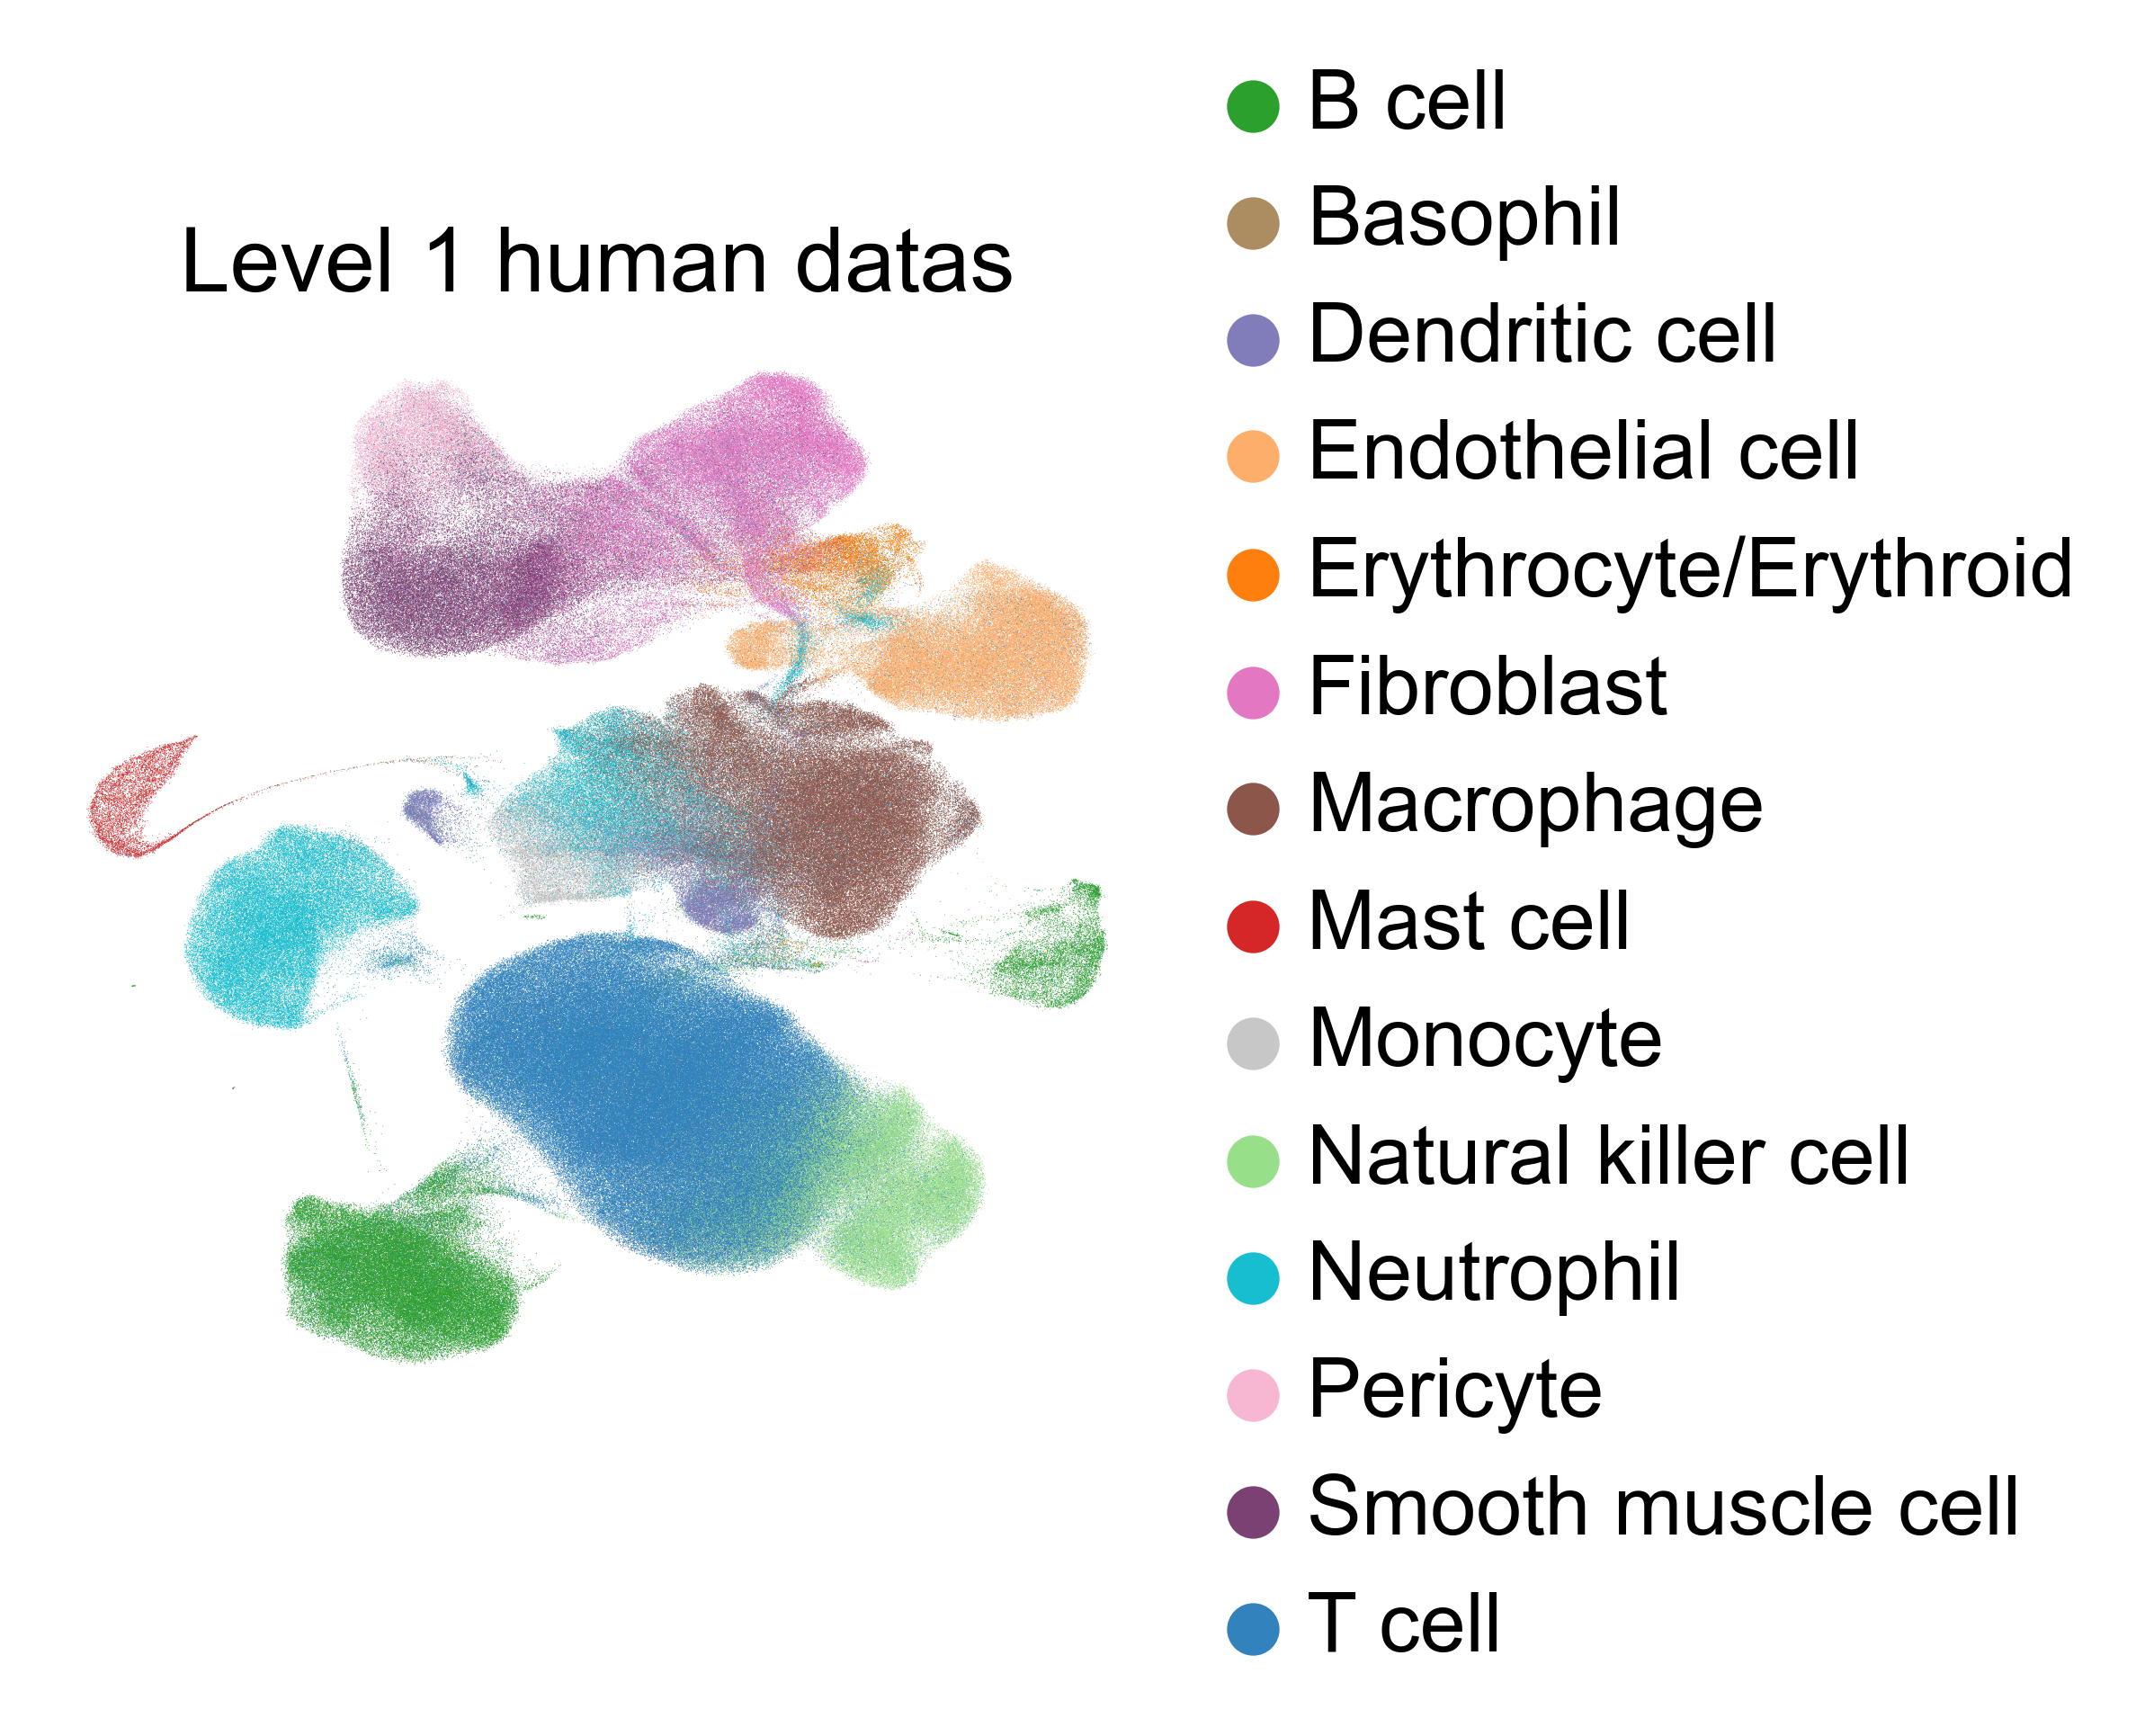

In [10]:
sc.pl.umap(
    adata,
    color='cell_type_level1_corrected',
    palette=color_palette_level1,
    show=True,
    frameon=False,
    title = "Level 1 human datas",
    # save="level1-withReference.pdf"
)